# reproducible coat lightgcn audit notebook

This executed notebook records the cached intermediate evidence used by `final_report.tex`: CUDA/device status, dataset summaries, run inventory, aggregate metrics, bootstrap intervals, mechanism diagnostics, and publication figures.

In [1]:
from pathlib import Path
import json
import pandas as pd
import torch
from IPython.display import Image, display

# resolve the workspace whether the notebook runs from notebooks/ or the workspace root
cwd = Path.cwd().resolve()
root = cwd if (cwd / 'artifacts').exists() else (cwd / '..').resolve()
print('workspace:', root)
print('cuda available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('cuda device:', torch.cuda.get_device_name(0))

workspace: /workspace/root/CPSC 483 finalproject/reproduceable_workspace
cuda available: True
cuda device: NVIDIA GeForce RTX 3060


In [2]:
dataset = pd.read_csv(root / 'artifacts' / 'dataset_summary.csv')

# this table checks that the train split is more popularity-concentrated than randomized test
display(dataset.round(4))

,dataset,split,users,items,interactions,density,avg_user_degree,avg_item_degree,positive_rate_r_ge_3,top_1_pct_share,top_5_pct_share,top_10_pct_share
0,Coat,train_mnar,290,300,6960,0.0800,24.0,23.2000,0.5204,0.0361,0.1431,0.2356
1,Coat,random_test,290,300,4640,0.0533,16.0,15.4667,0.4013,0.0172,0.0780,0.1463


In [3]:
manifest_path = root / 'artifacts' / 'run_manifest.json'
manifest = json.loads(manifest_path.read_text())
run_dirs = sorted((root / 'artifacts' / 'runs' / 'coat').glob('*/seed_*'))

# the manifest and directory count verify that the report uses cached runs, not fresh ad hoc numbers
print(json.dumps(manifest, indent=2))
print('cached run directories:', len(run_dirs))
print('example run:', run_dirs[0].relative_to(root))

{
  "n_runs": 18,
  "device": "NVIDIA GeForce RTX 3060",
  "summary_rows": 6,
  "bootstrap_rows": 4
}
cached run directories: 18
example run: artifacts/runs/coat/corrected_k2/seed_13


In [4]:
main = pd.read_csv(root / 'artifacts' / 'summaries' / 'main_results.csv')
cols = ['model', 'k_layers', 'gamma', 'residual', 'ndcg_mean', 'ndcg_std', 'recall_mean', 'recall_std', 'head_share_mean', 'js_mean', 'avg_runtime_seconds']

# rounded values are the exact source for the report table
main_display = main[cols].copy()
for col in main_display.columns:
    if col != 'model':
        main_display[col] = main_display[col].round(4)
display(main_display)

,model,k_layers,gamma,residual,ndcg_mean,ndcg_std,recall_mean,recall_std,head_share_mean,js_mean,avg_runtime_seconds
0,corrected_k2,2,0.35,0.2,0.6749,0.0023,0.4909,0.0038,0.1504,0.0469,9.6835
1,corrected_k2_stronger,2,0.70,0.2,0.6771,0.0020,0.4908,0.0026,0.1497,0.0431,9.7338
2,lightgcn_k1,1,0.00,0.0,0.6760,0.0048,0.4915,0.0017,0.1480,0.0452,8.0539
3,lightgcn_k2,2,0.00,0.0,0.6863,0.0028,0.5048,0.0043,0.1582,0.0537,9.4381
4,lightgcn_k3,3,0.00,0.0,0.6890,0.0042,0.5085,0.0054,0.1585,0.0599,12.8680
5,zero_hop,0,0.00,0.0,0.6517,0.0077,0.4686,0.0115,0.1362,0.0382,6.9642


In [5]:
boot = pd.read_csv(root / 'artifacts' / 'summaries' / 'bootstrap_summary.csv')

# paired bootstrap intervals answer whether improvements are stable across users
boot_display = boot.copy()
for col in ['mean_delta_ndcg_at_5', 'ci_low', 'ci_high']:
    boot_display[col] = boot_display[col].round(4)
display(boot_display)

,comparison,mean_delta_ndcg_at_5,ci_low,ci_high,n_users
0,lightgcn_k1 minus zero_hop,0.0243,0.0138,0.0349,281
1,lightgcn_k2 minus zero_hop,0.0347,0.0232,0.0464,281
2,lightgcn_k3 minus zero_hop,0.0373,0.0250,0.0494,281
3,corrected_k2 minus lightgcn_k2,-0.0114,-0.0193,-0.0034,281


In [6]:
mechanism = pd.read_csv(root / 'artifacts' / 'summaries' / 'mechanism_diagnostics.csv')
swaps = pd.read_csv(root / 'artifacts' / 'summaries' / 'swap_summary.csv')

# these diagnostics explain why degree tempering reduces popularity but hurts ranking accuracy
display(mechanism.round(4))
display(swaps.round(4))

,diagnostic,value
0,degree_vs_random_positive_rate_spearman,0.1907
1,degree_vs_random_positive_rate_pearson,0.1943
2,tail_quartile_random_positive_rate,0.3637
3,head_quartile_random_positive_rate,0.4428
4,corrected_k2_vanilla_only_label_rate,0.4482
5,corrected_k2_correction_only_label_rate,0.3815


,comparison,mean_top5_overlap,changed_items,vanilla_only_label_rate,correction_only_label_rate,vanilla_only_degree,correction_only_degree
0,corrected_k2,3.7768,1.2232,0.4482,0.3815,12.2896,10.0786
1,corrected_k2_stronger,3.7274,1.2726,0.4447,0.3859,12.6450,10.0164


fig5_causal_mechanism_diagnostics.png


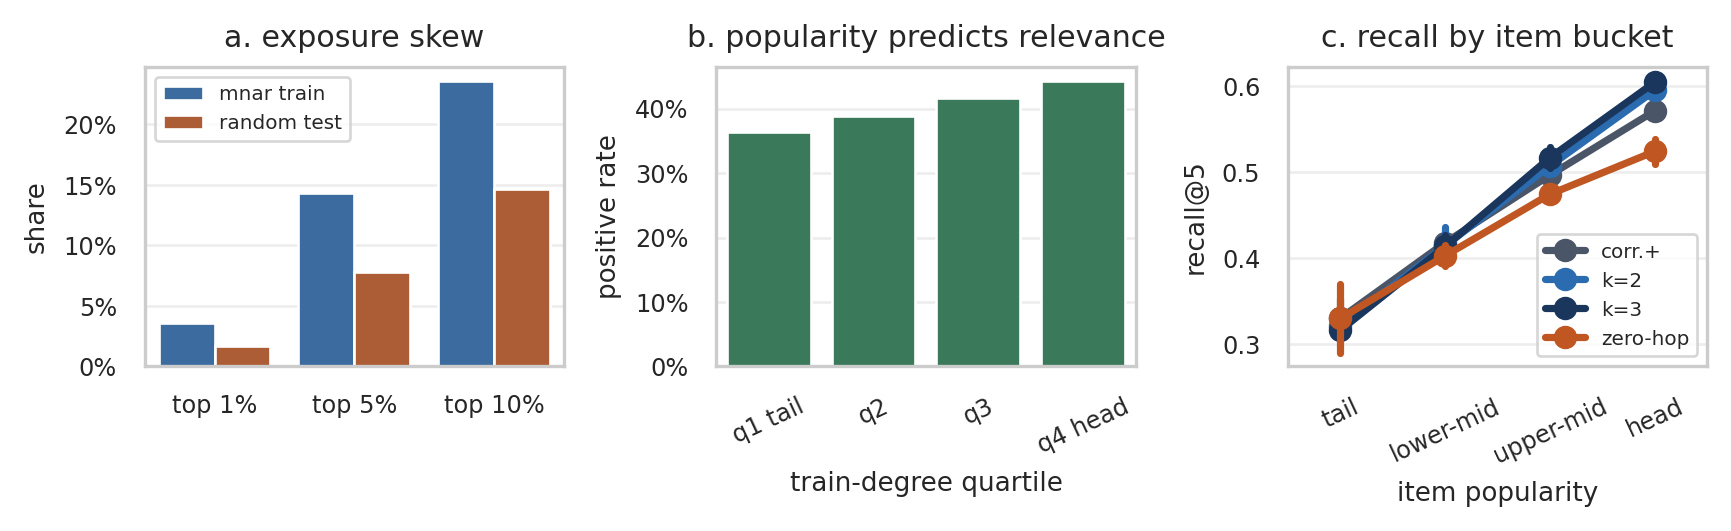

fig2_depth_sweep.png


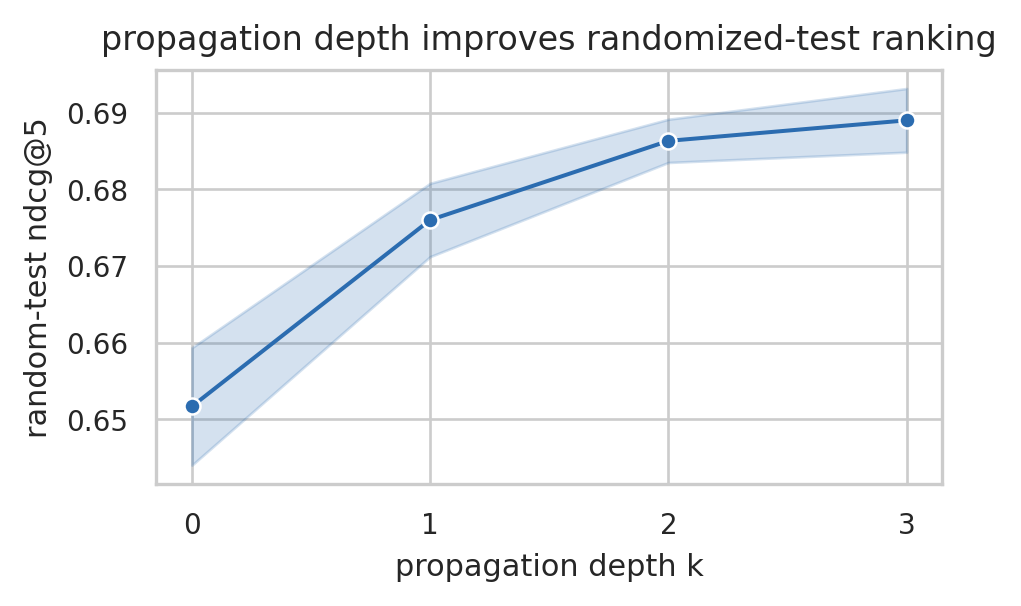

fig3_accuracy_bias_tradeoff.png


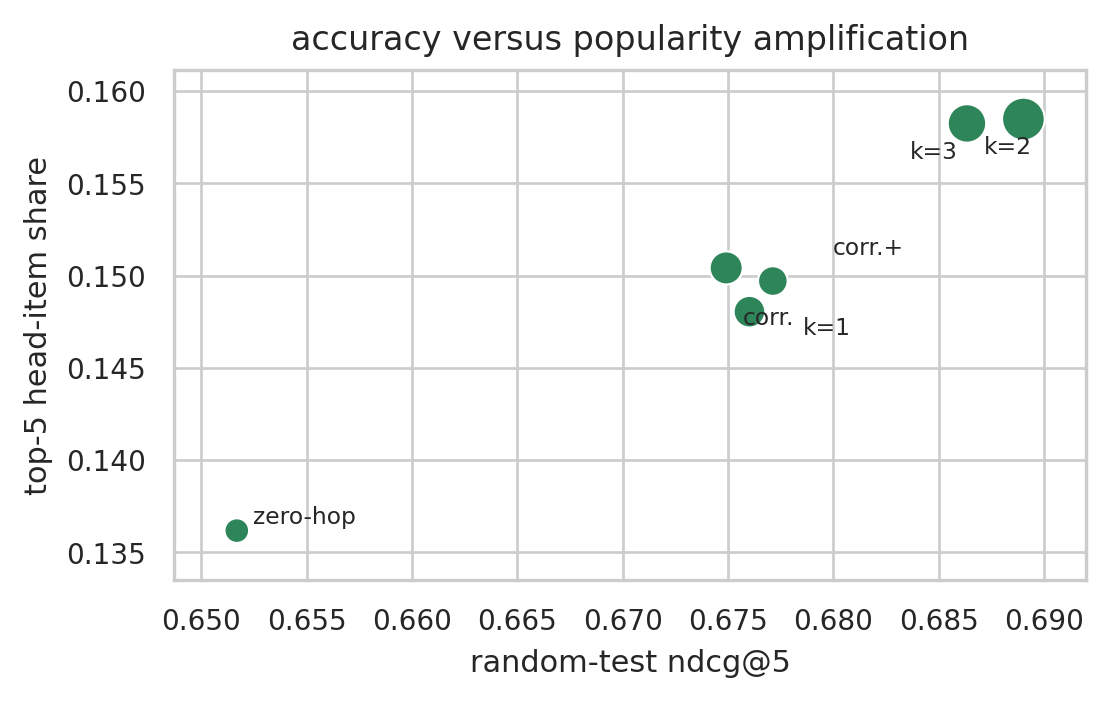

fig4_user_effects.png


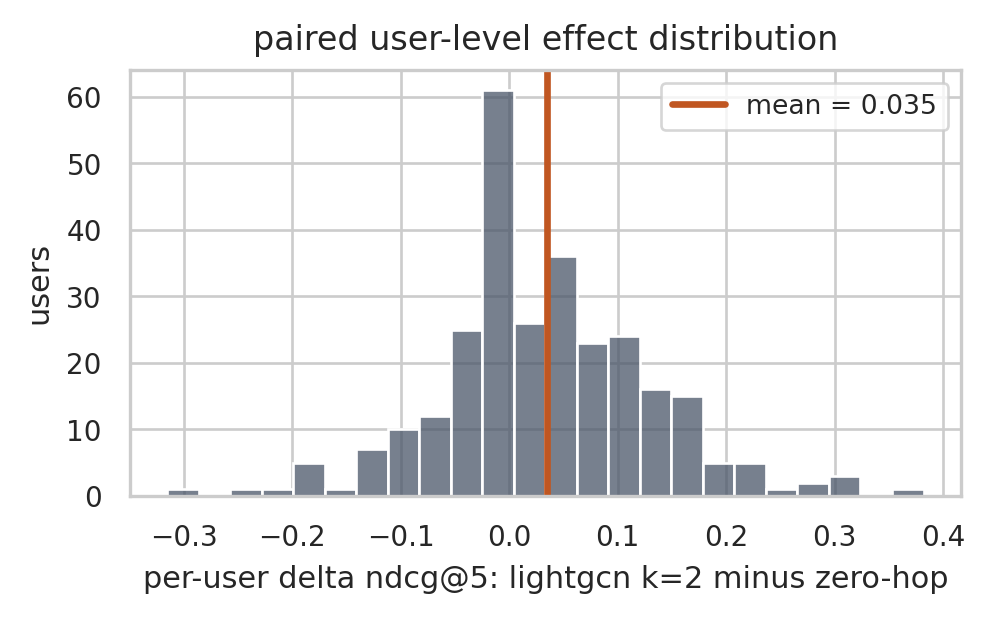

In [7]:
figures = [
    'fig5_causal_mechanism_diagnostics.png',
    'fig2_depth_sweep.png',
    'fig3_accuracy_bias_tradeoff.png',
    'fig4_user_effects.png',
]

# these are the same files included in the final latex report or appendix
for figure in figures:
    print(figure)
    display(Image(filename=str(root / 'figures' / figure)))

## interpretation checkpoint

The randomized Coat test set supports RQ1: graph propagation improves ranking quality over zero-hop with paired bootstrap intervals above zero. RQ2 is not supported for the implemented correction: popularity tempering lowers concentration but replaces some relevant higher-degree recommendations with less relevant lower-degree ones.